In [1]:
import kagglehub
import os

# Download dataset(data set directly download gareko)
path = kagglehub.dataset_download(
    "maulikgajera/brain-tumor-mri-dataset"
)

print("Dataset path:")
print(path)

print("\nFiles and folders:")
for item in os.listdir(path):
    print(item)

C:\Users\A C E R\Desktop\brain-tumor-classification\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 249M/249M [01:08<00:00, 3.80MB/s] 

Extracting files...


Dataset path:
C:\Users\A C E R\.cache\kagglehub\datasets\maulikgajera\brain-tumor-mri-dataset\versions\1

Files and folders:
🧠 Brain Tumor MRI Dataset


In [4]:
import os

# Find the paths automatically
classification_path = None
segmentation_path = None

for root, dirs, files in os.walk(path):
    if "classification_task" in dirs:
        classification_path = os.path.join(root, "classification_task")
    if "segmentation_task" in dirs:
        segmentation_path = os.path.join(root, "segmentation_task")

print("Classification path:")
print(classification_path)

print("\nSegmentation path:")
print(segmentation_path)

Classification path:
C:\Users\A C E R\.cache\kagglehub\datasets\maulikgajera\brain-tumor-mri-dataset\versions\1\🧠 Brain Tumor MRI Dataset\classification_task

Segmentation path:
C:\Users\A C E R\.cache\kagglehub\datasets\maulikgajera\brain-tumor-mri-dataset\versions\1\🧠 Brain Tumor MRI Dataset\segmentation_task


In [5]:
classes = ["glioma", "meningioma", "no_tumor", "pituitary"]

print("CLASSIFICATION DATASET")
print("=" * 40)

for split in ["train", "test"]:
    print(f"\n{split.upper()}")

    total = 0

    for class_name in classes:
        folder = os.path.join(
            classification_path,
            split,
            class_name
        )

        images = [
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{class_name:12} : {len(images)}")

        total += len(images)

    print(f"{'TOTAL':12} : {total}")

CLASSIFICATION DATASET

TRAIN
glioma       : 1147
meningioma   : 1329
no_tumor     : 1067
pituitary    : 1457
TOTAL        : 5000

TEST
glioma       : 254
meningioma   : 306
no_tumor     : 140
pituitary    : 300
TOTAL        : 1000


In [6]:
print("SEGMENTATION DATASET")
print("=" * 40)

for split in ["train", "test"]:

    image_folder = os.path.join(
        segmentation_path,
        split,
        "images"
    )

    mask_folder = os.path.join(
        segmentation_path,
        split,
        "masks"
    )

    images = [
        f for f in os.listdir(image_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    masks = [
        f for f in os.listdir(mask_folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    print(f"\n{split.upper()}")
    print("Images :", len(images))
    print("Masks  :", len(masks))

SEGMENTATION DATASET

TRAIN
Images : 3933
Masks  : 3933

TEST
Images : 860
Masks  : 860


In [11]:
import os
import pandas as pd

# Supported file extensions
image_extension = (".jpg", ".jpeg", ".png")
mask_extension = (".png", ".jpg", ".jpeg")


# Collect segmentation image-mask pairs
def collect_segmentation_pairs(image_dir, mask_dir):
    rows = []

    if not os.path.isdir(image_dir):
        raise ValueError(f"Segmentation image path not found: {image_dir}")

    if not os.path.isdir(mask_dir):
        raise ValueError(f"Segmentation mask path not found: {mask_dir}")

    # Store masks using filename without extension
    mask_paths = {}

    for root, _, files in os.walk(mask_dir):
        for file_name in files:

            if file_name.lower().endswith(mask_extension):

                mask_stem = os.path.splitext(file_name)[0]

                mask_paths[mask_stem] = os.path.join(
                    root,
                    file_name
                )

    # Find matching images
    for root, _, files in os.walk(image_dir):

        for file_name in files:

            if not file_name.lower().endswith(image_extension):
                continue

            image_stem = os.path.splitext(file_name)[0]

            # Check whether corresponding mask exists
            if image_stem in mask_paths:

                image_path = os.path.join(
                    root,
                    file_name
                )

                rows.append([
                    image_path,
                    mask_paths[image_stem]
                ])

    return pd.DataFrame(
        rows,
        columns=["image_path", "mask_path"]
    )


# Create training pairs
segmentation_train_df = collect_segmentation_pairs(
    SEGMENTATION_TRAIN_IMAGE_DIR,
    SEGMENTATION_TRAIN_MASK_DIR
)

# Create testing pairs
segmentation_test_df = collect_segmentation_pairs(
    SEGMENTATION_TEST_IMAGE_DIR,
    SEGMENTATION_TEST_MASK_DIR
)


# Check results
if segmentation_train_df.empty or segmentation_test_df.empty:
    raise ValueError(
        "Segmentation image/mask pairs were not found. "
        "Check the image and mask filenames."
    )


print("Segmentation train pairs:", len(segmentation_train_df))
print("Segmentation test pairs:", len(segmentation_test_df))

Segmentation train pairs: 3933
Segmentation test pairs: 860


In [12]:
import os

for i in range(5):
    image_path = segmentation_train_df.iloc[i]["image_path"]
    mask_path = segmentation_train_df.iloc[i]["mask_path"]

    print(f"\nPair {i + 1}")
    print("MRI  :", os.path.basename(image_path))
    print("Mask :", os.path.basename(mask_path))


Pair 1
MRI  : brisc2025_train_00001_gl_ax_t1.jpg
Mask : brisc2025_train_00001_gl_ax_t1.png

Pair 2
MRI  : brisc2025_train_00002_gl_ax_t1.jpg
Mask : brisc2025_train_00002_gl_ax_t1.png

Pair 3
MRI  : brisc2025_train_00003_gl_ax_t1.jpg
Mask : brisc2025_train_00003_gl_ax_t1.png

Pair 4
MRI  : brisc2025_train_00004_gl_ax_t1.jpg
Mask : brisc2025_train_00004_gl_ax_t1.png

Pair 5
MRI  : brisc2025_train_00005_gl_ax_t1.jpg
Mask : brisc2025_train_00005_gl_ax_t1.png


In [13]:
import os

matched = 0
not_matched = 0

for _, row in segmentation_train_df.iterrows():

    image_name = os.path.splitext(
        os.path.basename(row["image_path"])
    )[0]

    mask_name = os.path.splitext(
        os.path.basename(row["mask_path"])
    )[0]

    if image_name == mask_name:
        matched += 1
    else:
        not_matched += 1

print("Matched pairs    :", matched)
print("Not matched pairs:", not_matched)

Matched pairs    : 3933
Not matched pairs: 0


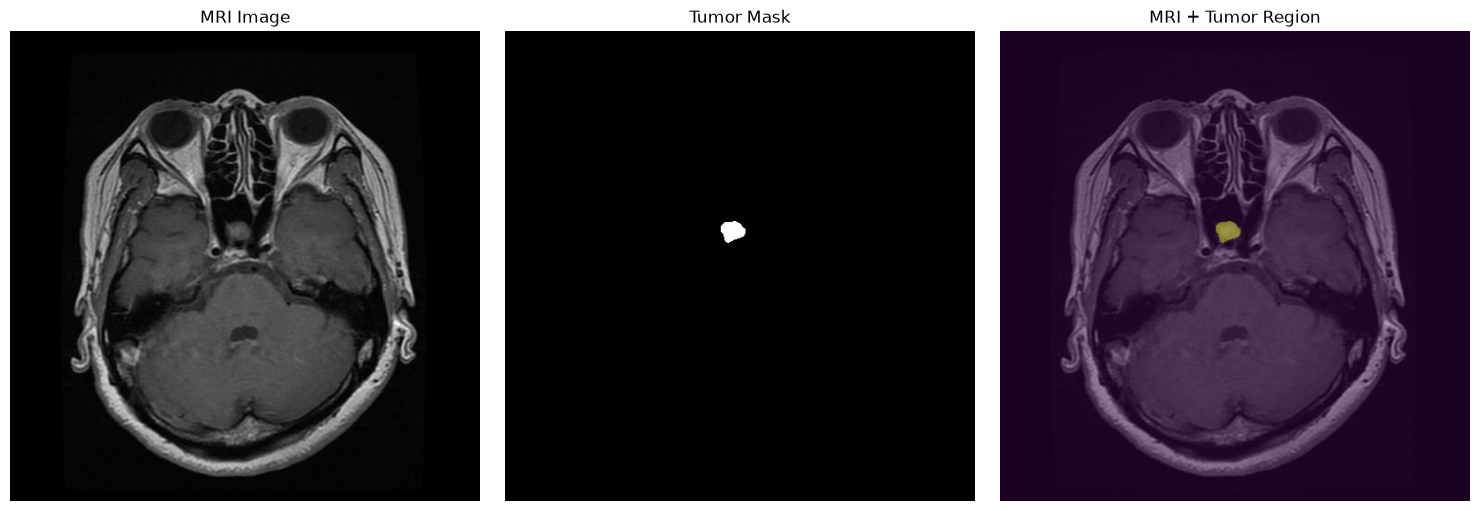

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Select one random image-mask pair
sample = segmentation_train_df.sample(1).iloc[0]

image = Image.open(sample["image_path"]).convert("L")
mask = Image.open(sample["mask_path"]).convert("L")

image_array = np.array(image)
mask_array = np.array(mask)

# Convert mask to binary
binary_mask = mask_array > 127

plt.figure(figsize=(15, 5))

# MRI
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

# Ground-truth mask
plt.subplot(1, 3, 2)
plt.imshow(binary_mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(image_array, cmap="gray")
plt.imshow(binary_mask, alpha=0.4)
plt.title("MRI + Tumor Region")
plt.axis("off")

plt.tight_layout()
plt.show()

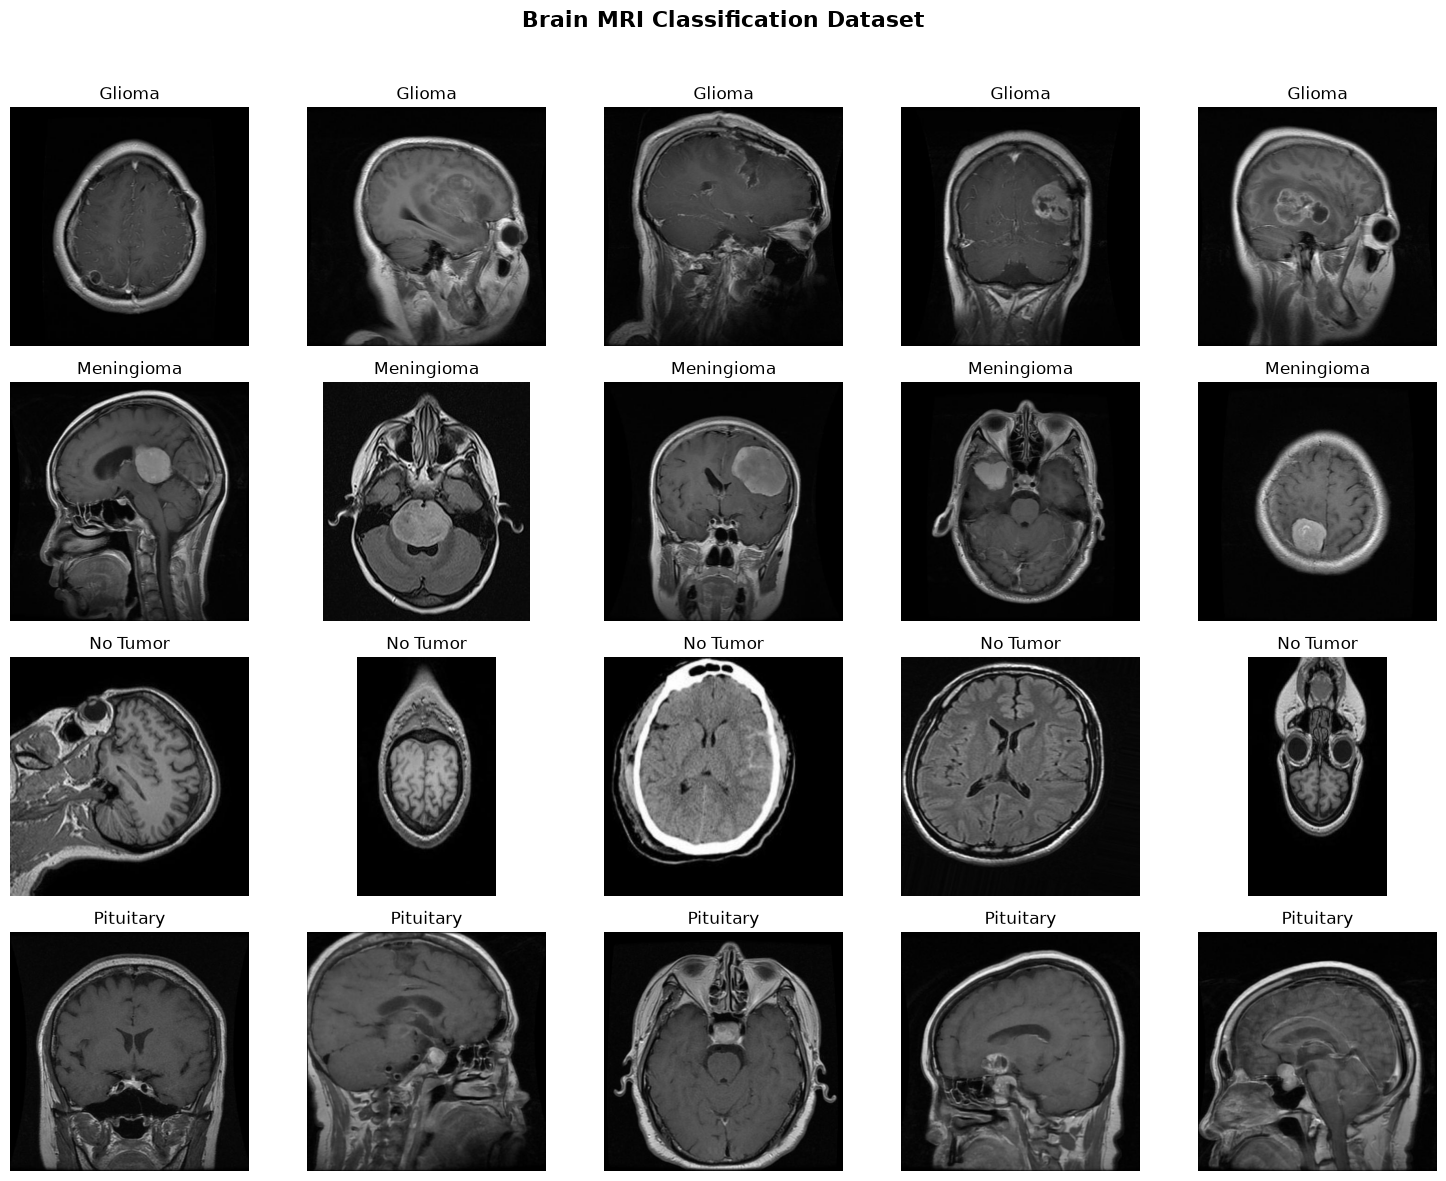

In [17]:
import matplotlib.pyplot as plt
from PIL import Image

samples_per_class = 5

fig, axes = plt.subplots(
    len(class_names),
    samples_per_class,
    figsize=(15, 12)
)

fig.suptitle(
    "Brain MRI Classification Dataset",
    fontsize=16,
    fontweight="bold"
)

for row, class_name in enumerate(class_names):

    class_df = df[
        (df["label"] == class_name) &
        (df["split"] == "train")
    ]

    samples = class_df.sample(
        n=min(samples_per_class, len(class_df)),
        random_state=42
    )

    for col in range(samples_per_class):

        ax = axes[row, col]

        if col >= len(samples):
            ax.axis("off")
            continue

        sample = samples.iloc[col]

        image = Image.open(
            sample["image_path"]
        ).convert("RGB")

        ax.imshow(image)

        ax.set_title(
            class_name.replace("_", " ").title()
        )

        ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

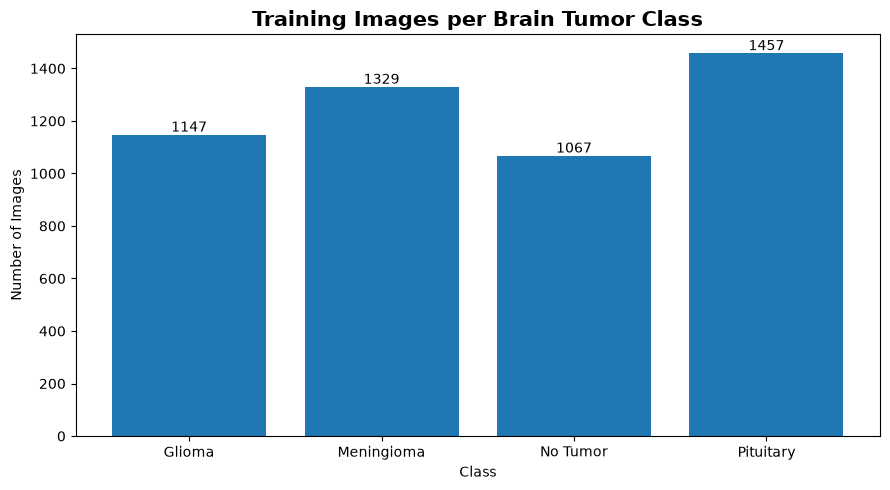

In [18]:
counts = (
    df[df["split"] == "train"]["label"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    counts.index,
    counts.values
)

plt.title(
    "Training Images per Brain Tumor Class",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(
    range(len(class_names)),
    [x.replace("_", " ").title() for x in class_names]
)

for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

# 80% Training, 20% Temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

# Split the remaining 20% into:
# 15% Validation and 5% Test
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.25,
    random_state=42,
    stratify=temp_df["label"]
)

# Check the sizes
print("Training images   :", len(train_df))
print("Validation images :", len(validation_df))
print("Testing images    :", len(test_df))

Training images   : 4800
Validation images : 900
Testing images    : 300


In [20]:
# Class distribution after splitting

distribution = pd.DataFrame({
    "Training": train_df["label"].value_counts(),
    "Validation": validation_df["label"].value_counts(),
    "Testing": test_df["label"].value_counts()
}).reindex(class_names, fill_value=0)

print("CLASS DISTRIBUTION AFTER SPLIT")
print("=" * 50)
print(distribution)

CLASS DISTRIBUTION AFTER SPLIT
            Training  Validation  Testing
label                                    
glioma          1121         210       70
meningioma      1308         245       82
no_tumor         966         181       60
pituitary       1405         264       88


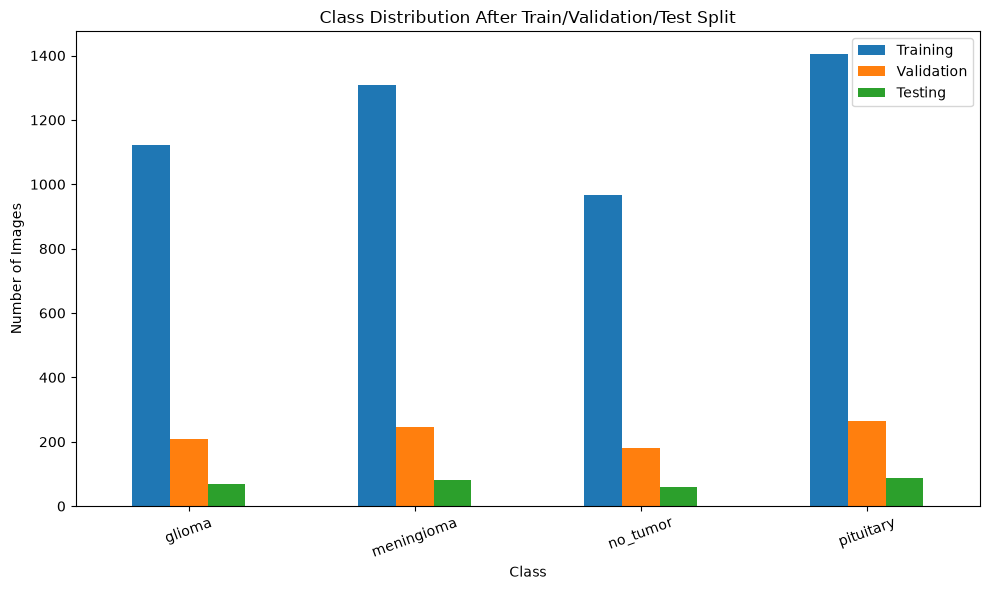

In [21]:
distribution.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Class Distribution After Train/Validation/Test Split")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [22]:
print("Training distribution:")
print(
    train_df["label"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

print("\nValidation distribution:")
print(
    validation_df["label"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

print("\nTest distribution:")
print(
    test_df["label"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

Training distribution:
label
glioma        1121
meningioma    1308
no_tumor       966
pituitary     1405
Name: count, dtype: int64

Validation distribution:
label
glioma        210
meningioma    245
no_tumor      181
pituitary     264
Name: count, dtype: int64

Test distribution:
label
glioma        70
meningioma    82
no_tumor      60
pituitary     88
Name: count, dtype: int64


In [23]:
# IMAGE PREPROCESSING FOR EFFICIENTNETB3(B3 vaneko = EfficientNet-B3, a specific version of the EfficientNet deep-learning model ho).
# Resize gareko : 300 x 300 ma 
# Color: RGB   rakheko 


import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (300, 300)

def preprocess_image(image_path, label):
    # Read image
    image = tf.io.read_file(image_path)

    # Decode image and convert to RGB
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize to 300 x 300
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # EfficientNet preprocessing ko lagi
    image = preprocess_input(image)

    return image, label

print("Preprocessing function created successfully.")
print("Image size:", IMG_SIZE)
print("Channels: RGB")

Preprocessing function created successfully.
Image size: (300, 300)
Channels: RGB


In [24]:
#checking split and documenting the augmentation setup.
print("TRAINING IMAGES PER CLASS:")
print(
    train_df["label"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

print("\nVALIDATION IMAGES PER CLASS:")
print(
    validation_df["label"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

print("\nTEST IMAGES PER CLASS:")
print(
    test_df["label"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

print("\nAUGMENTATION:")
print("Applied on-the-fly to training images only")
print("Saved augmented files: 0")
print("Image cache: not used")

TRAINING IMAGES PER CLASS:
label
glioma        1121
meningioma    1308
no_tumor       966
pituitary     1405
Name: count, dtype: int64

VALIDATION IMAGES PER CLASS:
label
glioma        210
meningioma    245
no_tumor      181
pituitary     264
Name: count, dtype: int64

TEST IMAGES PER CLASS:
label
glioma        70
meningioma    82
no_tumor      60
pituitary     88
Name: count, dtype: int64

AUGMENTATION:
Applied on-the-fly to training images only
Saved augmented files: 0
Image cache: not used


In [25]:
# CLASSIFICATION DATA PIPELINE
# EfficientNetB3 - 300 x 300 RGB

target_size = (300, 300)
batch_size = 32

# Convert class names to numbers
label_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

print("Label mapping:")
print(label_to_index)

# Data augmentation
# Training images only


classification_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.014),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomZoom(0.05)
])


# Load and preprocess image

def load_classification_image(image_path, label, training=False):

    # Read image
    image = tf.io.read_file(image_path)

    # Decode JPEG as RGB
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize  gareko
    image = tf.image.resize(
        image,
        target_size
    )

    # float32 ma Convert gareko
    image = tf.cast(
        image,
        tf.float32
    )

    # Apply augmentation only during training
    if training:
        image = classification_augmentation(
            image,
            training=True
        )

    return image, label



# paths and labels   Prepare gareko


train_paths = train_df["image_path"].values
train_labels = (
    train_df["label"]
    .map(label_to_index)
    .values
    .astype(np.int32)
)

validation_paths = validation_df["image_path"].values
validation_labels = (
    validation_df["label"]
    .map(label_to_index)
    .values
    .astype(np.int32)
)

test_paths = test_df["image_path"].values
test_labels = (
    test_df["label"]
    .map(label_to_index)
    .values
    .astype(np.int32)
)


#  dataset train gareko


train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_ds = train_ds.shuffle(
    len(train_df),
    seed=42,
    reshuffle_each_iteration=True
)

train_ds = train_ds.map(
    lambda path, label:
        load_classification_image(
            path,
            label,
            training=True
        ),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(batch_size)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)



#  dataset validation gareko


validation_ds = tf.data.Dataset.from_tensor_slices(
    (validation_paths, validation_labels)
)

validation_ds = validation_ds.map(
    lambda path, label:
        load_classification_image(
            path,
            label,
            training=False
        ),
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.batch(batch_size)
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)


# dataset test gareko

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

test_ds = test_ds.map(
    lambda path, label:
        load_classification_image(
            path,
            label,
            training=False
        ),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(batch_size)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)


print("\nClassification datasets are ready!")
print("Training batches   :", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches :", tf.data.experimental.cardinality(validation_ds).numpy())
print("Testing batches    :", tf.data.experimental.cardinality(test_ds).numpy())

Label mapping:
{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}

Classification datasets are ready!
Training batches   : 150
Validation batches : 29
Testing batches    : 10


In [26]:
# one batch   check gareko 
images, labels = next(iter(train_ds))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Image data type   :", images.dtype)
print("Image min value   :", tf.reduce_min(images).numpy())
print("Image max value   :", tf.reduce_max(images).numpy())
print("Labels            :", labels.numpy())

Image batch shape : (32, 300, 300, 3)
Label batch shape : (32,)
Image data type   : <dtype: 'float32'>
Image min value   : 0.0
Image max value   : 242.7418
Labels            : [3 3 3 2 0 2 0 2 3 0 3 3 3 0 1 3 3 2 0 3 3 3 2 1 1 3 3 3 3 3 2 3]


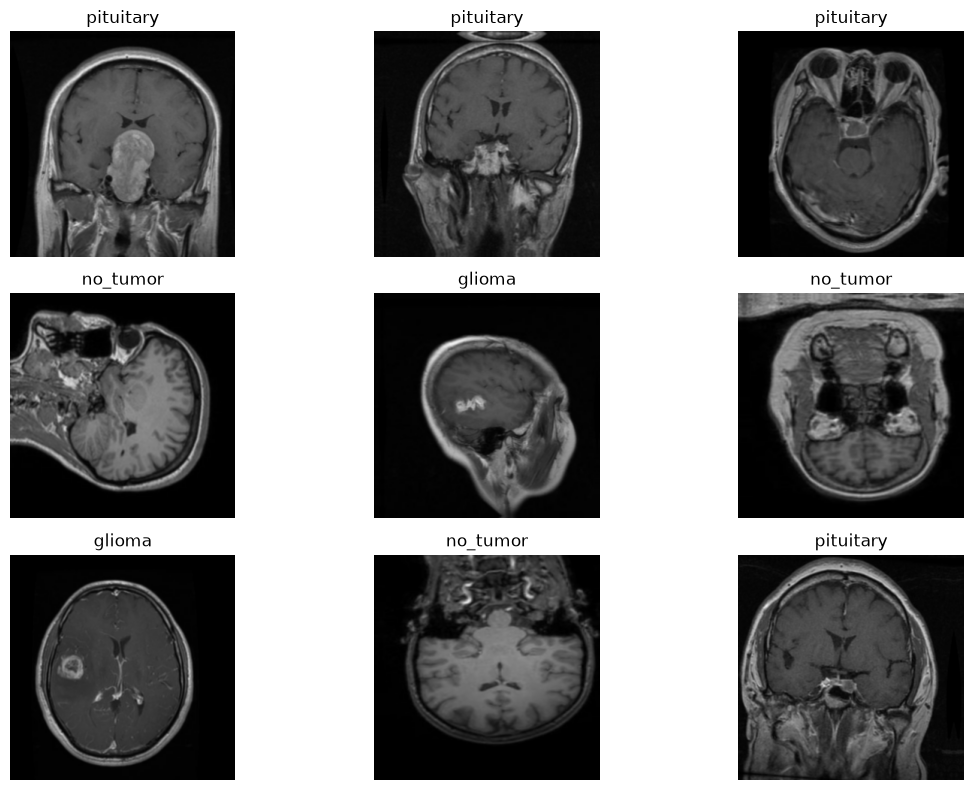

In [27]:
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# DATA AUGMENTATION(augmentation ley halka Zoom,Translation,Rotation garxa)



classification_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.014),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
    tf.keras.layers.RandomZoom(0.05)
])

print("Augmentation layer created successfully.")

Augmentation layer created successfully.


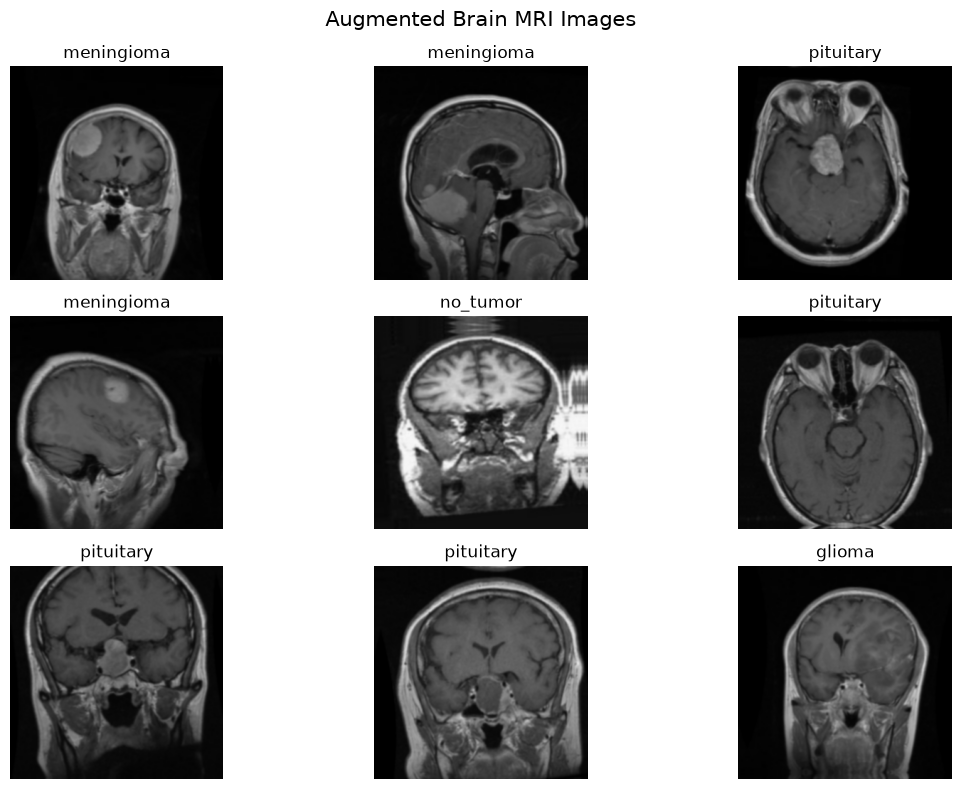

In [29]:
# VISUALIZE AUGMENTATION
sample_image, sample_label = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(9):

    augmented_image = classification_augmentation(
        sample_image[i:i+1],
        training=True
    )[0]

    plt.subplot(3, 3, i + 1)
    plt.imshow(
        augmented_image.numpy().astype("uint8")
    )
    plt.title(class_names[sample_label[i].numpy()])
    plt.axis("off")

plt.suptitle(
    "Augmented Brain MRI Images",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [30]:
#segmentation(yesley data laii 85% training,15% validation ra 100% of the separate test laii  untouched  rakhera split garxa)
seg_train_df, seg_validation_df = train_test_split(
    segmentation_train_df,
    test_size=0.15,
    random_state=42
)

print("segmentation training pairs   :", len(seg_train_df))
print("segmentation validation pairs :", len(seg_validation_df))
print("segmentation test pairs       :", len(segmentation_test_df))

segmentation training pairs   : 3343
segmentation validation pairs : 590
segmentation test pairs       : 860


In [31]:
# segmentation dataset pipeline
def load_segmentation_pair(image_path, mask_path):
    # Load MRI image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, target_size)
    image = tf.cast(image, tf.float32) / 255.0

    # Load tumor mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, target_size, method="nearest")
    mask = tf.cast(mask, tf.float32) / 255.0

    # Convert mask to binary
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return image, mask


# Training dataset
seg_train_ds = tf.data.Dataset.from_tensor_slices(
    (
        seg_train_df["image_path"].values,
        seg_train_df["mask_path"].values
    )
)

seg_train_ds = seg_train_ds.shuffle(
    len(seg_train_df),
    seed=42,
    reshuffle_each_iteration=True
)

seg_train_ds = seg_train_ds.map(
    load_segmentation_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

seg_train_ds = seg_train_ds.batch(16).prefetch(tf.data.AUTOTUNE)


# Validation dataset
seg_validation_ds = tf.data.Dataset.from_tensor_slices(
    (
        seg_validation_df["image_path"].values,
        seg_validation_df["mask_path"].values
    )
)

seg_validation_ds = seg_validation_ds.map(
    load_segmentation_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

seg_validation_ds = seg_validation_ds.batch(16).prefetch(tf.data.AUTOTUNE)


# Test dataset
seg_test_ds = tf.data.Dataset.from_tensor_slices(
    (
        segmentation_test_df["image_path"].values,
        segmentation_test_df["mask_path"].values
    )
)

seg_test_ds = seg_test_ds.map(
    load_segmentation_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

seg_test_ds = seg_test_ds.batch(16).prefetch(tf.data.AUTOTUNE)


# Verify the pipeline
seg_images, seg_masks = next(iter(seg_train_ds))

print("segmentation batch images:", seg_images.shape)
print("segmentation batch masks :", seg_masks.shape)

segmentation batch images: (16, 300, 300, 3)
segmentation batch masks : (16, 300, 300, 1)


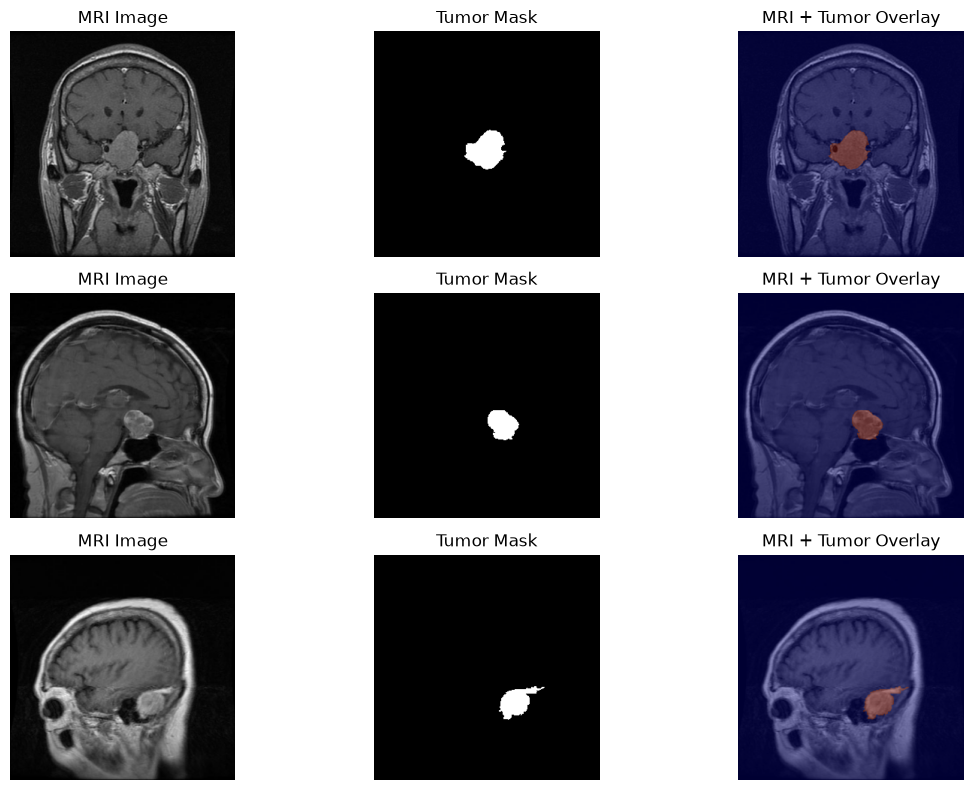

In [32]:
import matplotlib.pyplot as plt

seg_images, seg_masks = next(iter(seg_train_ds))

plt.figure(figsize=(12, 8))

for i in range(3):
    # MRI
    plt.subplot(3, 3, i * 3 + 1)
    plt.imshow(seg_images[i])
    plt.title("MRI Image")
    plt.axis("off")

    # Mask
    plt.subplot(3, 3, i * 3 + 2)
    plt.imshow(seg_masks[i].numpy().squeeze(), cmap="gray")
    plt.title("Tumor Mask")
    plt.axis("off")

    # Overlay
    plt.subplot(3, 3, i * 3 + 3)
    plt.imshow(seg_images[i])
    plt.imshow(
        seg_masks[i].numpy().squeeze(),
        alpha=0.4,
        cmap="jet"
    )
    plt.title("MRI + Tumor Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
#U-Net segmentation model banako  
from tensorflow.keras import layers, Model


def conv_block(x, filters):
    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)

    return x


def build_unet(input_shape=(300, 300, 3)):

    inputs = layers.Input(shape=input_shape)

   
    # Encoder


    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck


    c4 = conv_block(p3, 256)

    # Decoder

    u3 = layers.Conv2DTranspose(
        128, 2,
        strides=2,
        padding="same"
    )(c4)

    u3 = layers.Resizing(
        c3.shape[1],
        c3.shape[2]
    )(u3)

    u3 = layers.Concatenate()([u3, c3])
    c5 = conv_block(u3, 128)


    u2 = layers.Conv2DTranspose(
        64, 2,
        strides=2,
        padding="same"
    )(c5)

    u2 = layers.Resizing(
        c2.shape[1],
        c2.shape[2]
    )(u2)

    u2 = layers.Concatenate()([u2, c2])
    c6 = conv_block(u2, 64)


    u1 = layers.Conv2DTranspose(
        32, 2,
        strides=2,
        padding="same"
    )(c6)

    u1 = layers.Resizing(
        c1.shape[1],
        c1.shape[2]
    )(u1)

    u1 = layers.Concatenate()([u1, c1])
    c7 = conv_block(u1, 32)


 
    # Output

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(c7)

    return Model(inputs, outputs)


segmentation_model = build_unet()

segmentation_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 300, 300, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 300, 300, 32)      │             896 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_8         │ (None, 300, 300, 32)      │             128 │ conv2d_8[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 300, 300, 32)      │           9,248 │ batch_normalization_8[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_9         │ (None, 300, 300, 32)      │             128 │ conv2d_9[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 150, 150, 32)      │               0 │ batch_normalization_9[0][… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_10 (Conv2D)            │ (None, 150, 150, 64)      │          18,496 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_10        │ (None, 150, 150, 64)      │             256 │ conv2d_10[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_11 (Conv2D)            │ (None, 150, 150, 64)      │          36,928 │ batch_normalization_10[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_11        │ (None, 150, 150, 64)      │             256 │ conv2d_11[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_4               │ (None, 75, 75, 64)        │               0 │ batch_normalization_11[0]… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_12 (Conv2D)            │ (None, 75, 75, 128)       │          73,856 │ max_pooling2d_4[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_12        │ (None, 75, 75, 128)       │             512 │ conv2d_12[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_13 (Conv2D)            │ (None, 75, 75, 128)       │         147,58

 Total params: 1,931,233 (7.37 MB)

 Trainable params: 1,928,417 (7.36 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [35]:
import tensorflow as tf


def dice_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true * y_pred, axis=1)

    dice = (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true, axis=1)
        + tf.reduce_sum(y_pred, axis=1)
        + smooth
    )

    return tf.reduce_mean(dice)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_score(y_true, y_pred)


def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    return tf.reduce_mean(bce) + dice_loss(
        y_true,
        y_pred
    )


def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])

    union = (
        tf.reduce_sum(y_true, axis=[1, 2, 3])
        + tf.reduce_sum(y_pred, axis=[1, 2, 3])
        - intersection
    )

    iou = (intersection + smooth) / (union + smooth)

    return tf.reduce_mean(iou)


print("Segmentation loss and metrics are ready!")

Segmentation loss and metrics are ready!


In [36]:
#U-net treaning ko lagi ready banako
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Compile the segmentation model
segmentation_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[
        dice_score,
        iou_score
    ]
)


# Stop training if validation performance stops improving
early_stopping = EarlyStopping(
    monitor="val_dice_score",
    mode="max",
    patience=8,
    restore_best_weights=True,
    verbose=1
)


# Reduce learning rate when validation performance plateaus
reduce_lr = ReduceLROnPlateau(
    monitor="val_dice_score",
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)


# Save the best segmentation model
model_checkpoint = ModelCheckpoint(
    "best_unet_segmentation.keras",
    monitor="val_dice_score",
    mode="max",
    save_best_only=True,
    verbose=1
)


print("Segmentation model compiled successfully!")
print("Optimizer: Adam")
print("Learning rate: 0.0001")
print("Loss: Binary Cross-Entropy + Dice Loss")
print("Metrics: Dice Score + IoU")

Segmentation model compiled successfully!
Optimizer: Adam
Learning rate: 0.0001
Loss: Binary Cross-Entropy + Dice Loss
Metrics: Dice Score + IoU


In [37]:
# Take one batch from the segmentation dataset
seg_images, seg_masks = next(iter(seg_train_ds))

# Generate predictions
pred_masks = segmentation_model(seg_images, training=False)

print("Input images shape :", seg_images.shape)
print("True masks shape   :", seg_masks.shape)
print("Predicted masks shape:", pred_masks.shape)

Input images shape : (16, 300, 300, 3)
True masks shape   : (16, 300, 300, 1)
Predicted masks shape: (16, 300, 300, 1)


In [38]:
SEG_EPOCHS = 20

seg_history = segmentation_model.fit(
    seg_train_ds,
    validation_data=seg_validation_ds,
    epochs=SEG_EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ]
)

Epoch 1/20


C:\Users\A C E R\Desktop\brain-tumor-classification\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - dice_score: 0.0472 - iou_score: 0.0623 - loss: 1.6084
Epoch 1: val_dice_score improved from None to 0.03083, saving model to best_unet_segmentation.keras

Epoch 1: finished saving model to best_unet_segmentation.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 1188s 6s/step - dice_score: 0.0472 - iou_score: 0.0623 - loss: 1.6084 - val_dice_score: 0.0308 - val_iou_score: 0.0021 - val_loss: 1.4761 - learning_rate: 1.0000e-04
Epoch 2/20
132/209 ━━━━━━━━━━━━━━━━━━━━ 7:25 6s/step - dice_score: 0.0593 - iou_score: 0.2115 - loss: 1.4742

KeyboardInterrupt: 

In [39]:
print("Training interrupted successfully.")
print("Best model from Epoch 1 was saved as:")
print("best_unet_segmentation.keras")

Training interrupted successfully.
Best model from Epoch 1 was saved as:
best_unet_segmentation.keras


In [41]:
#heavy u net vako ley light weight banako 
from tensorflow.keras import layers, Model


def conv_block_light(x, filters):
    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)

    return x


def build_light_unet(input_shape=(300, 300, 3)):

    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block_light(inputs, 16)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = conv_block_light(p1, 32)
    p2 = layers.MaxPooling2D(2)(c2)

    c3 = conv_block_light(p2, 64)
    p3 = layers.MaxPooling2D(2)(c3)

    # Bottleneck
    c4 = conv_block_light(p3, 128)

    # Decoder
    u3 = layers.Conv2DTranspose(
        64, 2,
        strides=2,
        padding="same"
    )(c4)

    u3 = layers.Resizing(
        c3.shape[1],
        c3.shape[2]
    )(u3)

    u3 = layers.Concatenate()([u3, c3])
    c5 = conv_block_light(u3, 64)

    u2 = layers.Conv2DTranspose(
        32, 2,
        strides=2,
        padding="same"
    )(c5)

    u2 = layers.Resizing(
        c2.shape[1],
        c2.shape[2]
    )(u2)

    u2 = layers.Concatenate()([u2, c2])
    c6 = conv_block_light(u2, 32)

    u1 = layers.Conv2DTranspose(
        16, 2,
        strides=2,
        padding="same"
    )(c6)

    u1 = layers.Resizing(
        c1.shape[1],
        c1.shape[2]
    )(u1)

    u1 = layers.Concatenate()([u1, c1])
    c7 = conv_block_light(u1, 16)

    # Output tumor mask
    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(c7)

    return Model(inputs, outputs)


# Create lightweight U-Net
segmentation_model = build_light_unet()

segmentation_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 300, 300, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_23 (Conv2D)            │ (None, 300, 300, 16)      │             448 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_22        │ (None, 300, 300, 16)      │              64 │ conv2d_23[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_24 (Conv2D)            │ (None, 300, 300, 16)      │           2,320 │ batch_normalization_22[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_23        │ (None, 300, 300, 16)      │              64 │ conv2d_24[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_6               │ (None, 150, 150, 16)      │               0 │ batch_normalization_23[0]… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_25 (Conv2D)            │ (None, 150, 150, 32)      │           4,640 │ max_pooling2d_6[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_24        │ (None, 150, 150, 32)      │             128 │ conv2d_25[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_26 (Conv2D)            │ (None, 150, 150, 32)      │           9,248 │ batch_normalization_24[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_25        │ (None, 150, 150, 32)      │             128 │ conv2d_26[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_7               │ (None, 75, 75, 32)        │               0 │ batch_normalization_25[0]… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_27 (Conv2D)            │ (None, 75, 75, 64)        │          18,496 │ max_pooling2d_7[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_26        │ (None, 75, 75, 64)        │             256 │ conv2d_27[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_28 (Conv2D)            │ (None, 75, 75, 64)        │          36,92

 Total params: 484,849 (1.85 MB)

 Trainable params: 483,441 (1.84 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [42]:
segmentation_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[
        dice_score,
        iou_score
    ]
)

print("Lightweight U-Net compiled successfully!")
print("Loss    : Binary Cross-Entropy + Dice Loss")
print("Metrics : Dice Score + IoU")
print("Optimizer: Adam")
print("Learning rate: 0.0001")

Lightweight U-Net compiled successfully!
Loss    : Binary Cross-Entropy + Dice Loss
Metrics : Dice Score + IoU
Optimizer: Adam
Learning rate: 0.0001


In [44]:
SEG_IMG_SIZE = (256, 256)

def load_segmentation_pair(image_path, mask_path):
    # Load MRI image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, SEG_IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    # Load tumor mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(
        mask,
        SEG_IMG_SIZE,
        method="nearest"
    )
    mask = tf.cast(mask, tf.float32) / 255.0

    # Binary mask
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return image, mask


seg_train_ds = tf.data.Dataset.from_tensor_slices(
    (
        seg_train_df["image_path"].values,
        seg_train_df["mask_path"].values
    )
)

seg_train_ds = seg_train_ds.shuffle(
    len(seg_train_df),
    seed=42,
    reshuffle_each_iteration=True
)

seg_train_ds = seg_train_ds.map(
    load_segmentation_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

seg_train_ds = seg_train_ds.batch(16).prefetch(
    tf.data.AUTOTUNE
)


seg_validation_ds = tf.data.Dataset.from_tensor_slices(
    (
        seg_validation_df["image_path"].values,
        seg_validation_df["mask_path"].values
    )
)

seg_validation_ds = seg_validation_ds.map(
    load_segmentation_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

seg_validation_ds = seg_validation_ds.batch(16).prefetch(
    tf.data.AUTOTUNE
)


seg_test_ds = tf.data.Dataset.from_tensor_slices(
    (
        segmentation_test_df["image_path"].values,
        segmentation_test_df["mask_path"].values
    )
)

seg_test_ds = seg_test_ds.map(
    load_segmentation_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

seg_test_ds = seg_test_ds.batch(16).prefetch(
    tf.data.AUTOTUNE
)

print("Segmentation image size:", SEG_IMG_SIZE)
print("Segmentation datasets updated!")

Segmentation image size: (256, 256)
Segmentation datasets updated!


In [45]:
from tensorflow.keras import layers, Model

def conv_block_light(x, filters):
    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)

    return x


def build_light_unet(input_shape=(256, 256, 3)):

    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block_light(inputs, 16)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = conv_block_light(p1, 32)
    p2 = layers.MaxPooling2D(2)(c2)

    c3 = conv_block_light(p2, 64)
    p3 = layers.MaxPooling2D(2)(c3)

    # Bottleneck
    c4 = conv_block_light(p3, 128)

    # Decoder
    u3 = layers.Conv2DTranspose(
        64, 2,
        strides=2,
        padding="same"
    )(c4)
    u3 = layers.Resizing(
        c3.shape[1],
        c3.shape[2]
    )(u3)
    u3 = layers.Concatenate()([u3, c3])
    c5 = conv_block_light(u3, 64)

    u2 = layers.Conv2DTranspose(
        32, 2,
        strides=2,
        padding="same"
    )(c5)
    u2 = layers.Resizing(
        c2.shape[1],
        c2.shape[2]
    )(u2)
    u2 = layers.Concatenate()([u2, c2])
    c6 = conv_block_light(u2, 32)

    u1 = layers.Conv2DTranspose(
        16, 2,
        strides=2,
        padding="same"
    )(c6)
    u1 = layers.Resizing(
        c1.shape[1],
        c1.shape[2]
    )(u1)
    u1 = layers.Concatenate()([u1, c1])
    c7 = conv_block_light(u1, 16)

    # Tumor mask
    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(c7)

    return Model(inputs, outputs)


segmentation_model = build_light_unet()

segmentation_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_38 (Conv2D)            │ (None, 256, 256, 16)      │             448 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_36        │ (None, 256, 256, 16)      │              64 │ conv2d_38[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_39 (Conv2D)            │ (None, 256, 256, 16)      │           2,320 │ batch_normalization_36[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_37        │ (None, 256, 256, 16)      │              64 │ conv2d_39[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_9               │ (None, 128, 128, 16)      │               0 │ batch_normalization_37[0]… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_40 (Conv2D)            │ (None, 128, 128, 32)      │           4,640 │ max_pooling2d_9[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_38        │ (None, 128, 128, 32)      │             128 │ conv2d_40[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_41 (Conv2D)            │ (None, 128, 128, 32)      │           9,248 │ batch_normalization_38[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_39        │ (None, 128, 128, 32)      │             128 │ conv2d_41[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_10              │ (None, 64, 64, 32)        │               0 │ batch_normalization_39[0]… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_42 (Conv2D)            │ (None, 64, 64, 64)        │          18,496 │ max_pooling2d_10[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_40        │ (None, 64, 64, 64)        │             256 │ conv2d_42[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_43 (Conv2D)            │ (None, 64, 64, 64)        │          36,92

 Total params: 484,849 (1.85 MB)

 Trainable params: 483,441 (1.84 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [46]:
segmentation_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[
        dice_score,
        iou_score
    ]
)

print("256×256 Lightweight U-Net compiled successfully!")

256×256 Lightweight U-Net compiled successfully!


In [47]:
quick_test = segmentation_model.fit(
    seg_train_ds,
    epochs=1,
    steps_per_epoch=10,
    verbose=1
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - dice_score: 0.0333 - iou_score: 0.0187 - loss: 1.7778


In [48]:
validation_test = segmentation_model.evaluate(
    seg_validation_ds,
    steps=5,
    verbose=1
)

print("Validation test completed!")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 381ms/step - dice_score: 0.0366 - iou_score: 0.0166 - loss: 1.6620
Validation test completed!


In [50]:
SEG_IMG_SIZE = (128, 128)

def load_segmentation_pair(image_path, mask_path):
    # MRI image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, SEG_IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    # Tumor mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(
        mask,
        SEG_IMG_SIZE,
        method="nearest"
    )
    mask = tf.cast(mask, tf.float32) / 255.0

    # Binary mask
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return image, mask


# Training dataset
seg_train_ds = tf.data.Dataset.from_tensor_slices(
    (
        seg_train_df["image_path"].values,
        seg_train_df["mask_path"].values
    )
)

seg_train_ds = seg_train_ds.shuffle(
    len(seg_train_df),
    seed=42,
    reshuffle_each_iteration=True
)

seg_train_ds = seg_train_ds.map(
    load_segmentation_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

seg_train_ds = seg_train_ds.batch(16).prefetch(
    tf.data.AUTOTUNE
)


# Validation dataset
seg_validation_ds = tf.data.Dataset.from_tensor_slices(
    (
        seg_validation_df["image_path"].values,
        seg_validation_df["mask_path"].values
    )
)

seg_validation_ds = seg_validation_ds.map(
    load_segmentation_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

seg_validation_ds = seg_validation_ds.batch(16).prefetch(
    tf.data.AUTOTUNE
)


# Test dataset
seg_test_ds = tf.data.Dataset.from_tensor_slices(
    (
        segmentation_test_df["image_path"].values,
        segmentation_test_df["mask_path"].values
    )
)

seg_test_ds = seg_test_ds.map(
    load_segmentation_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

seg_test_ds = seg_test_ds.batch(16).prefetch(
    tf.data.AUTOTUNE
)


print("Segmentation size:", SEG_IMG_SIZE)
print("Training pairs   :", len(seg_train_df))
print("Validation pairs :", len(seg_validation_df))
print("Test pairs       :", len(segmentation_test_df))

Segmentation size: (128, 128)
Training pairs   : 3343
Validation pairs : 590
Test pairs       : 860


In [51]:
from tensorflow.keras import layers, Model

def conv_block_light(x, filters):
    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        filters, 3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)

    return x


def build_light_unet(input_shape=(128, 128, 3)):

    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block_light(inputs, 16)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = conv_block_light(p1, 32)
    p2 = layers.MaxPooling2D(2)(c2)

    c3 = conv_block_light(p2, 64)
    p3 = layers.MaxPooling2D(2)(c3)

    # Bottleneck
    c4 = conv_block_light(p3, 128)

    # Decoder
    u3 = layers.Conv2DTranspose(
        64, 2, strides=2, padding="same"
    )(c4)
    u3 = layers.Concatenate()([u3, c3])
    c5 = conv_block_light(u3, 64)

    u2 = layers.Conv2DTranspose(
        32, 2, strides=2, padding="same"
    )(c5)
    u2 = layers.Concatenate()([u2, c2])
    c6 = conv_block_light(u2, 32)

    u1 = layers.Conv2DTranspose(
        16, 2, strides=2, padding="same"
    )(c6)
    u1 = layers.Concatenate()([u1, c1])
    c7 = conv_block_light(u1, 16)

    # Tumor mask
    outputs = layers.Conv2D(
        1, 1,
        activation="sigmoid"
    )(c7)

    return Model(inputs, outputs)


segmentation_model = build_light_unet()

print("128×128 Lightweight U-Net created!")
print("Input shape :", segmentation_model.input_shape)
print("Output shape:", segmentation_model.output_shape)

128×128 Lightweight U-Net created!
Input shape : (None, 128, 128, 3)
Output shape: (None, 128, 128, 1)


In [52]:
segmentation_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[
        dice_score,
        iou_score
    ]
)

print("128×128 Lightweight U-Net compiled successfully!")

128×128 Lightweight U-Net compiled successfully!


In [53]:
quick_test = segmentation_model.fit(
    seg_train_ds,
    epochs=1,
    steps_per_epoch=10,
    verbose=1
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 305ms/step - dice_score: 0.0387 - iou_score: 0.0247 - loss: 1.7494


In [54]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_dice_score",
    mode="max",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_dice_score",
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "best_light_unet_128.keras",
    monitor="val_dice_score",
    mode="max",
    save_best_only=True,
    verbose=1
)

seg_history = segmentation_model.fit(
    seg_train_ds,
    validation_data=seg_validation_ds,
    epochs=5,
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - dice_score: 0.0460 - iou_score: 0.0527 - loss: 1.6239
Epoch 1: val_dice_score improved from None to 0.03313, saving model to best_light_unet_128.keras

Epoch 1: finished saving model to best_light_unet_128.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 65s 312ms/step - dice_score: 0.0460 - iou_score: 0.0527 - loss: 1.6239 - val_dice_score: 0.0331 - val_iou_score: 0.0568 - val_loss: 1.5417 - learning_rate: 1.0000e-04
Epoch 2/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - dice_score: 0.0598 - iou_score: 0.1851 - loss: 1.5030
Epoch 2: val_dice_score improved from 0.03313 to 0.05733, saving model to best_light_unet_128.keras

Epoch 2: finished saving model to best_light_unet_128.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 64s 305ms/step - dice_score: 0.0598 - iou_score: 0.1851 - loss: 1.5030 - val_dice_score: 0.0573 - val_iou_score: 0.2688 - val_loss: 1.4639 - learning_rate: 1.0000e-04
Epoch 3/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - dice_score: 0.06

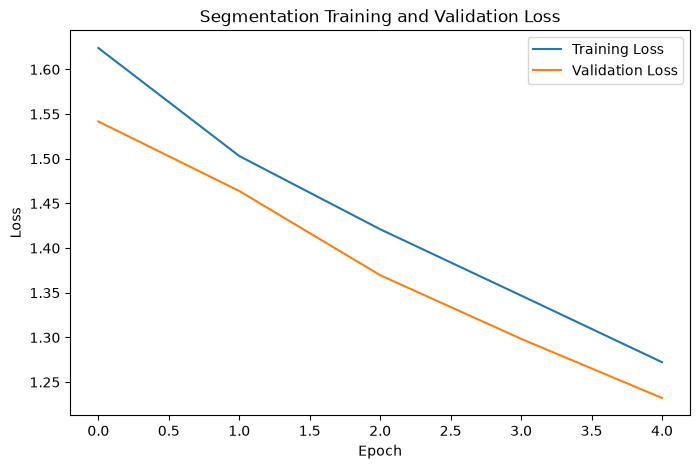

In [55]:
import matplotlib.pyplot as plt

history = seg_history.history

plt.figure(figsize=(8, 5))
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Segmentation Training and Validation Loss")
plt.legend()
plt.show()

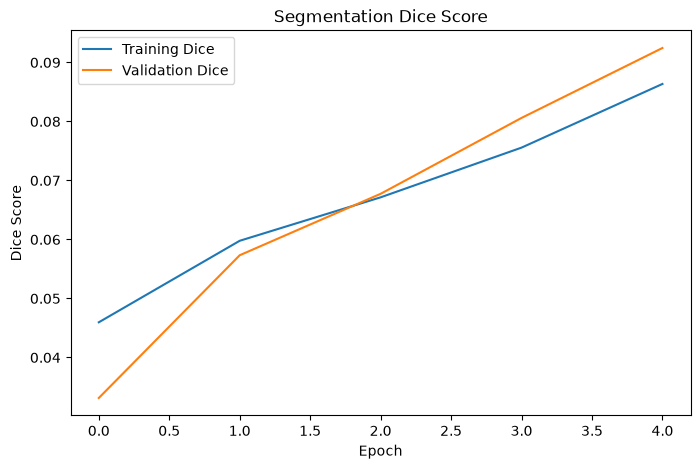

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["dice_score"],
    label="Training Dice"
)

plt.plot(
    history["val_dice_score"],
    label="Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Segmentation Dice Score")
plt.legend()
plt.show()

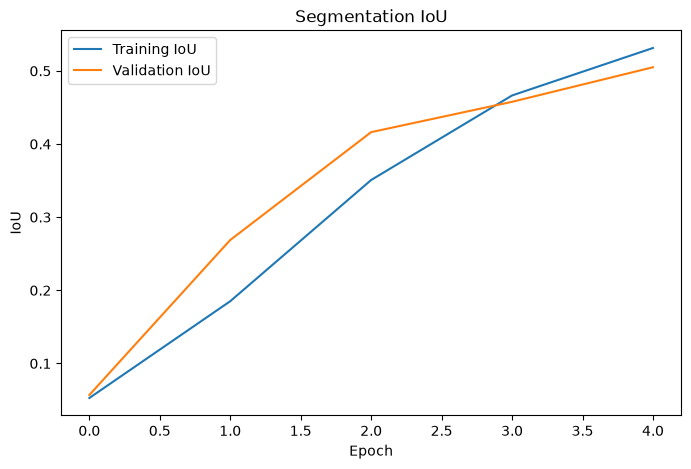

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["iou_score"],
    label="Training IoU"
)

plt.plot(
    history["val_iou_score"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Segmentation IoU")
plt.legend()
plt.show()

In [58]:
def dice_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true * y_pred, axis=1)

    dice = (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true, axis=1)
        + tf.reduce_sum(y_pred, axis=1)
        + smooth
    )

    return tf.reduce_mean(dice)


def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true * y_pred, axis=1)

    union = (
        tf.reduce_sum(y_true, axis=1)
        + tf.reduce_sum(y_pred, axis=1)
        - intersection
    )

    iou = (intersection + smooth) / (union + smooth)

    return tf.reduce_mean(iou)


print("Dice and IoU metrics updated!")

Dice and IoU metrics updated!


In [59]:
segmentation_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[
        dice_score,
        iou_score
    ]
)

print("Model recompiled with corrected Dice and IoU metrics")

Model recompiled with corrected Dice and IoU metrics


In [60]:
test_results = segmentation_model.evaluate(
    seg_test_ds,
    verbose=1
)

print("\nFinal Segmentation Test Results")
print(f"Test Loss : {test_results[0]:.4f}")
print(f"Test Dice : {test_results[1]:.4f}")
print(f"Test IoU  : {test_results[2]:.4f}")

54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - dice_score: 0.6389 - iou_score: 0.5129 - loss: 0.6914

Final Segmentation Test Results
Test Loss : 0.6914
Test Dice : 0.6389
Test IoU  : 0.5129


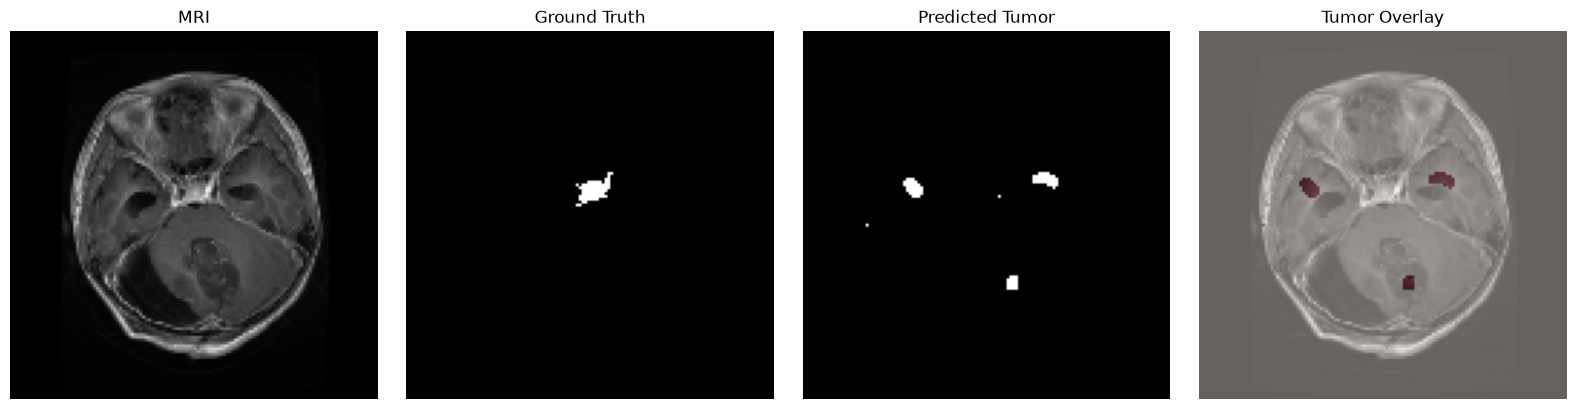

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Get one test batch
test_images, test_masks = next(iter(seg_test_ds))

# Predict tumor masks
pred_masks = segmentation_model.predict(
    test_images,
    verbose=0
)

# Select first image
image = test_images[0].numpy()
true_mask = test_masks[0].numpy().squeeze()
pred_mask = pred_masks[0].squeeze()

# Convert prediction to binary mask
pred_binary = (pred_mask > 0.5).astype(np.float32)

# Create overlay
overlay = image.copy()
overlay[pred_binary > 0] = [1.0, 0.0, 0.0]

# Display
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title("MRI")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(true_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_binary, cmap="gray")
plt.title("Predicted Tumor")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(image)
plt.imshow(pred_binary, alpha=0.4, cmap="Reds")
plt.title("Tumor Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

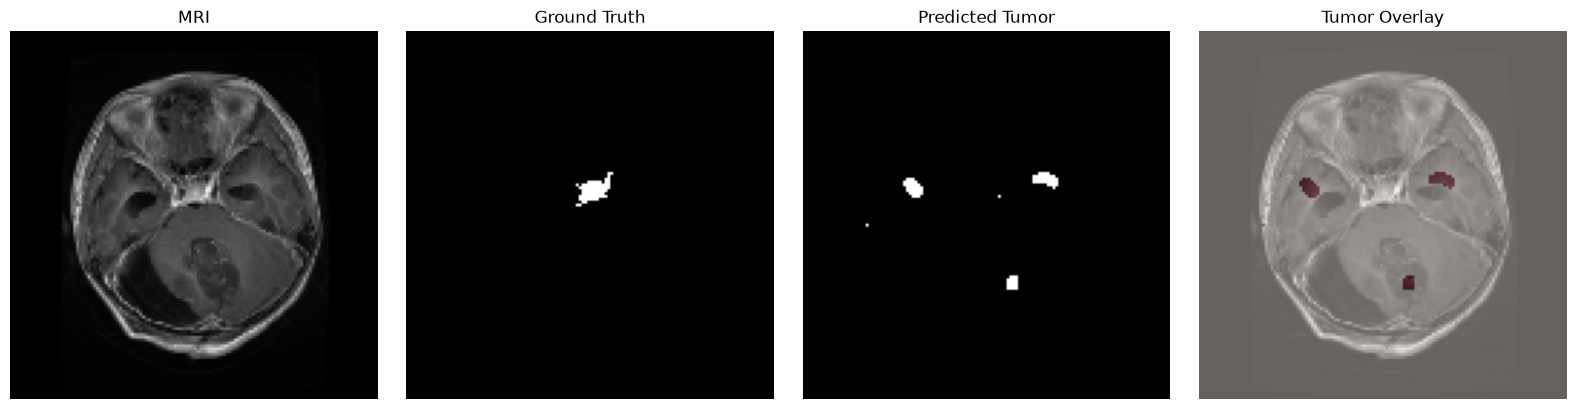

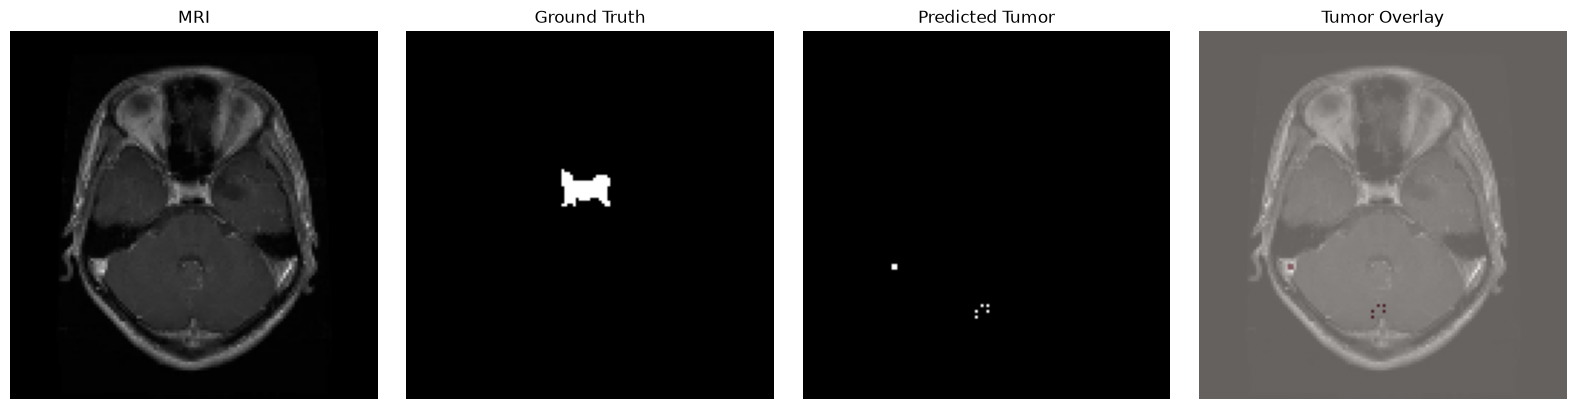

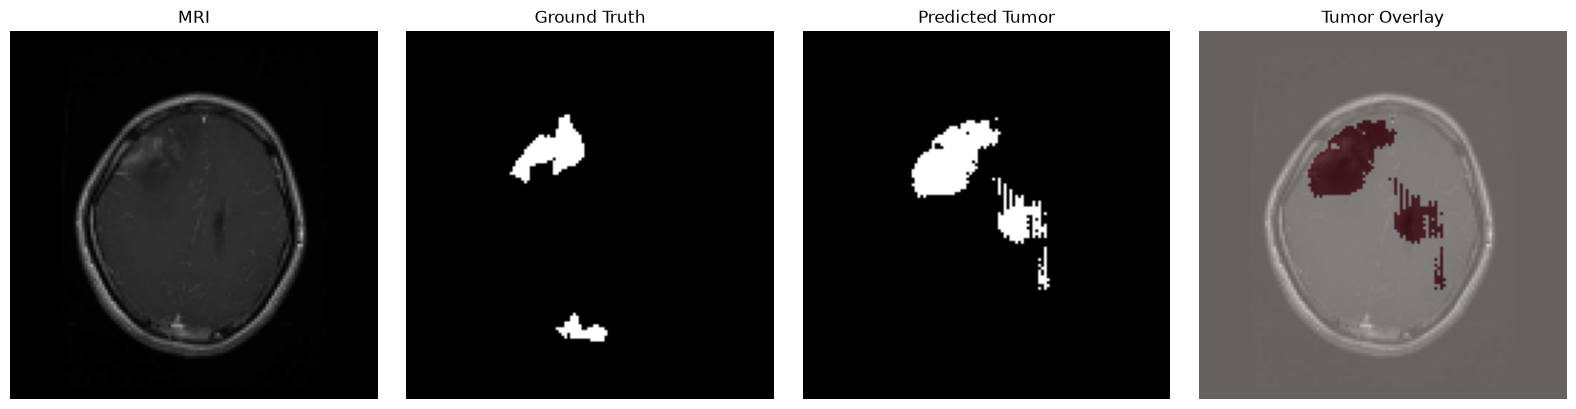

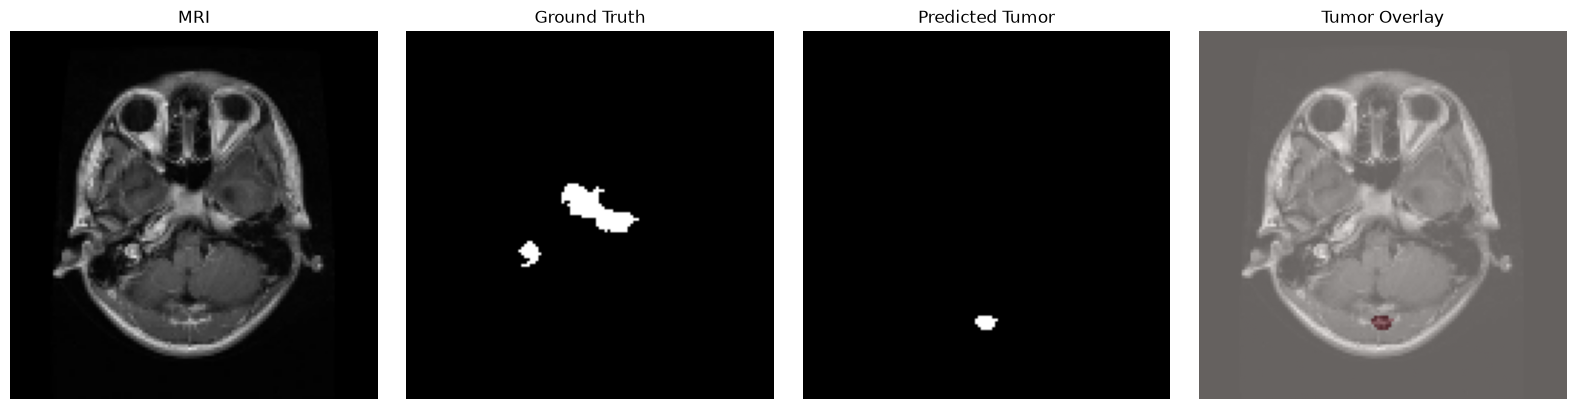

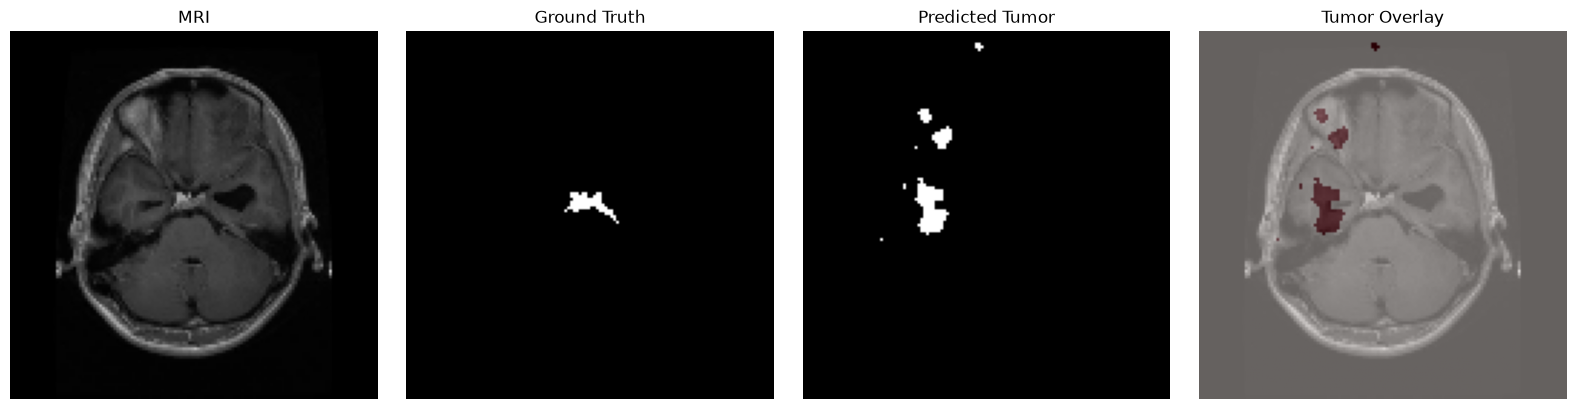

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Get one test batch
test_images, test_masks = next(iter(seg_test_ds))

# Predict masks
pred_masks = segmentation_model.predict(
    test_images,
    verbose=0
)

# Show 5 examples
for i in range(5):

    image = test_images[i].numpy()
    true_mask = test_masks[i].numpy().squeeze()
    pred_mask = pred_masks[i].squeeze()

    # Binary prediction
    pred_binary = (pred_mask > 0.5).astype(np.float32)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title("MRI")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred_binary, cmap="gray")
    plt.title("Predicted Tumor")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(image)
    plt.imshow(pred_binary, alpha=0.4, cmap="Reds")
    plt.title("Tumor Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [64]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3

NUM_CLASSES = 4
IMG_SIZE = (300, 300)

base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(300, 300, 3)
)

# Freeze the pretrained model initially
base_model.trainable = False

inputs = layers.Input(shape=(300, 300, 3))

x = base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

classification_model = Model(
    inputs,
    outputs
)

print("EfficientNetB3 classifier created!")
print("Input :", classification_model.input_shape)
print("Output:", classification_model.output_shape)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 79s 2us/step
EfficientNetB3 classifier created!
Input : (None, 300, 300, 3)
Output: (None, 4)


In [65]:
classification_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB3 classifier compiled!")
print("Loss     : Sparse Categorical Crossentropy")
print("Metric   : Accuracy")
print("Learning : 0.001")

EfficientNetB3 classifier compiled!
Loss     : Sparse Categorical Crossentropy
Metric   : Accuracy
Learning : 0.001


In [66]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

classification_checkpoint = ModelCheckpoint(
    "best_efficientnetb3_frozen.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

classification_early_stopping = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

classification_reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy",
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

classification_history = classification_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=5,
    callbacks=[
        classification_checkpoint,
        classification_early_stopping,
        classification_reduce_lr
    ],
    verbose=1
)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7325 - loss: 0.6996
Epoch 1: val_accuracy improved from None to 0.83889, saving model to best_efficientnetb3_frozen.keras

Epoch 1: finished saving model to best_efficientnetb3_frozen.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.7325 - loss: 0.6996 - val_accuracy: 0.8389 - val_loss: 0.4356 - learning_rate: 0.0010
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8496 - loss: 0.4285
Epoch 2: val_accuracy did not improve from 0.83889

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
150/150 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.8496 - loss: 0.4285 - val_accuracy: 0.8122 - val_loss: 0.4337 - learning_rate: 0.0010
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8567 - loss: 0.3805
Epoch 3: val_accuracy did not improve from 0.83889

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
150/150 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/s

In [67]:
# Progressive fine-tuning of EfficientNetB3

# Unfreeze the backbone
base_model.trainable = True

# Keep most layers frozen, fine-tune only the last 50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers[-50:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Recompile with a much smaller learning rate
classification_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning setup complete!")
print("Trainable layers:", sum(
    layer.trainable for layer in classification_model.layers
))

Fine-tuning setup complete!
Trainable layers: 5


In [68]:
classification_finetune_history = classification_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=5,
    callbacks=[
        ModelCheckpoint(
            "best_efficientnetb3_finetuned.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=2,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_accuracy",
            mode="max",
            factor=0.5,
            patience=1,
            min_lr=1e-7,
            verbose=1
        )
    ],
    verbose=1
)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8433 - loss: 0.4093
Epoch 1: val_accuracy improved from None to 0.81778, saving model to best_efficientnetb3_finetuned.keras

Epoch 1: finished saving model to best_efficientnetb3_finetuned.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.8433 - loss: 0.4093 - val_accuracy: 0.8178 - val_loss: 0.4515 - learning_rate: 1.0000e-05
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8737 - loss: 0.3375
Epoch 2: val_accuracy improved from 0.81778 to 0.84111, saving model to best_efficientnetb3_finetuned.keras

Epoch 2: finished saving model to best_efficientnetb3_finetuned.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.8737 - loss: 0.3375 - val_accuracy: 0.8411 - val_loss: 0.3925 - learning_rate: 1.0000e-05
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8908 - loss: 0.2927
Epoch 3: val_accuracy improved from 0.84111 to 0.85778, saving model to best_efficientnetb3_finetuned

In [69]:
# Evaluate the final EfficientNetB3 model on the unseen test set

test_loss, test_accuracy = classification_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFinal Classification Test Results")

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8833 - loss: 0.3039

Final Classification Test Results
Test Loss     : 0.3039
Test Accuracy : 0.8833
Test Accuracy : 88.33%


Classification Report
              precision    recall  f1-score   support

      glioma     0.9194    0.8143    0.8636        70
  meningioma     0.8841    0.7439    0.8079        82
    no_tumor     1.0000    0.9833    0.9916        60
   pituitary     0.8000    1.0000    0.8889        88

    accuracy                         0.8833       300
   macro avg     0.9009    0.8854    0.8880       300
weighted avg     0.8908    0.8833    0.8814       300


Confusion Matrix
[[57  7  0  6]
 [ 5 61  0 16]
 [ 0  1 59  0]
 [ 0  0  0 88]]


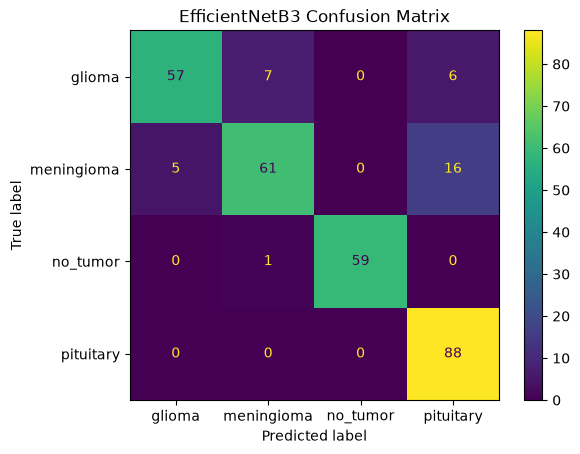

In [70]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = classification_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print("Classification Report")


print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix")

print(cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("EfficientNetB3 Confusion Matrix")
plt.show()

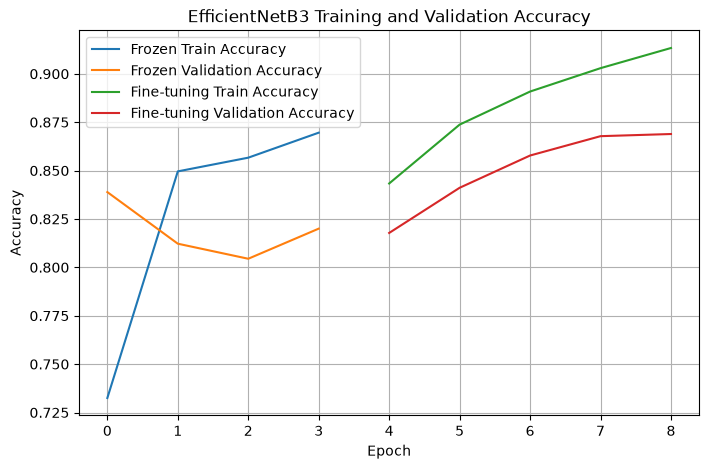

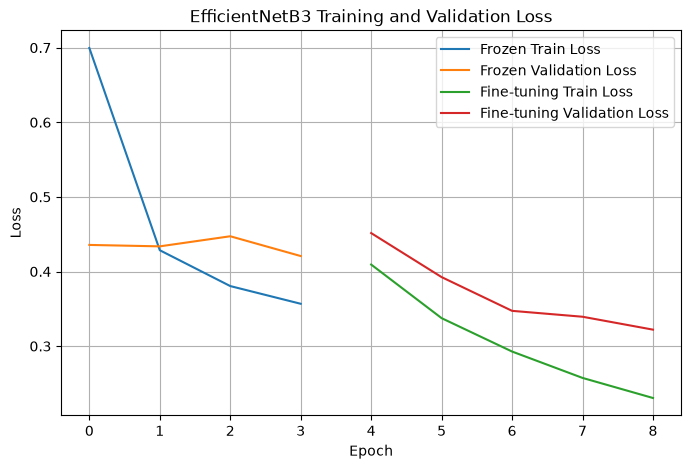

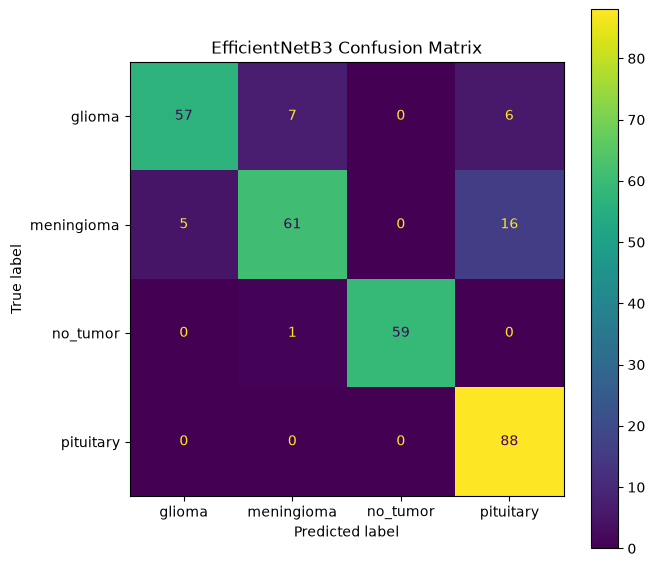

In [71]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


#  Training Curves


plt.figure(figsize=(8, 5))

plt.plot(
    classification_history.history["accuracy"],
    label="Frozen Train Accuracy"
)
plt.plot(
    classification_history.history["val_accuracy"],
    label="Frozen Validation Accuracy"
)

plt.plot(
    range(
        len(classification_history.history["accuracy"]),
        len(classification_history.history["accuracy"]) +
        len(classification_finetune_history.history["accuracy"])
    ),
    classification_finetune_history.history["accuracy"],
    label="Fine-tuning Train Accuracy"
)

plt.plot(
    range(
        len(classification_history.history["val_accuracy"]),
        len(classification_history.history["val_accuracy"]) +
        len(classification_finetune_history.history["val_accuracy"])
    ),
    classification_finetune_history.history["val_accuracy"],
    label="Fine-tuning Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB3 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()



# Loss Curves


plt.figure(figsize=(8, 5))

plt.plot(
    classification_history.history["loss"],
    label="Frozen Train Loss"
)
plt.plot(
    classification_history.history["val_loss"],
    label="Frozen Validation Loss"
)

plt.plot(
    range(
        len(classification_history.history["loss"]),
        len(classification_history.history["loss"]) +
        len(classification_finetune_history.history["loss"])
    ),
    classification_finetune_history.history["loss"],
    label="Fine-tuning Train Loss"
)

plt.plot(
    range(
        len(classification_history.history["val_loss"]),
        len(classification_history.history["val_loss"]) +
        len(classification_finetune_history.history["val_loss"])
    ),
    classification_finetune_history.history["val_loss"],
    label="Fine-tuning Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB3 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()



# Confusion Matrix


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax)

plt.title("EfficientNetB3 Confusion Matrix")
plt.show()

In [72]:
classification_model.save("best_efficientnetb3_final.keras")

print(" Final EfficientNetB3 model saved!")
print("File: best_efficientnetb3_final.keras")

 Final EfficientNetB3 model saved!
File: best_efficientnetb3_final.keras


In [73]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image


# Integrated Brain Tumor Prediction


def predict_brain_mri(image_path):
    """
    Complete pipeline:
    MRI -> EfficientNetB3 classification -> U-Net segmentation
    """


    # Load original image
    
    original_image = Image.open(image_path).convert("RGB")
    original_image = np.array(original_image)

   
    # Prepare image for EfficientNetB3
  
    classification_image = tf.image.resize(
        original_image,
        (300, 300)
    )

    classification_image = tf.cast(
        classification_image,
        tf.float32
    )

    classification_image = tf.expand_dims(
        classification_image,
        axis=0
    )

  
    # Classification
   
    probabilities = classification_model.predict(
        classification_image,
        verbose=0
    )[0]

    predicted_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_index]
    confidence = probabilities[predicted_index] * 100

    print("=" * 55)
    print("        BRAIN MRI ANALYSIS")
    print("=" * 55)

    print(f"\nPredicted Class : {predicted_class}")
    print(f"Confidence      : {confidence:.2f}%")

    print("\nClass Probabilities:")
    for name, probability in zip(class_names, probabilities):
        print(f"  {name:<12}: {probability * 100:.2f}%")


    # No tumor

    if predicted_class == "no_tumor":

        print("\nResult: No tumor class predicted.")
        print("Segmentation was not performed.")

        plt.figure(figsize=(6, 6))
        plt.imshow(original_image)
        plt.axis("off")
        plt.title(
            f"Prediction: {predicted_class} ({confidence:.2f}%)"
        )
        plt.show()

        return {
            "class": predicted_class,
            "confidence": confidence,
            "probabilities": probabilities,
            "mask": None
        }

   
    # Tumor detected 
   

    segmentation_image = tf.image.resize(
        original_image,
        (128, 128)
    )

    segmentation_image = (
        tf.cast(segmentation_image, tf.float32) / 255.0
    )

    segmentation_input = tf.expand_dims(
        segmentation_image,
        axis=0
    )

    predicted_mask = segmentation_model.predict(
        segmentation_input,
        verbose=0
    )[0, :, :, 0]

    # Binary mask
    binary_mask = (predicted_mask > 0.5).astype(np.uint8)

    # Resize mask to original image size
    original_height, original_width = original_image.shape[:2]

    resized_mask = tf.image.resize(
        binary_mask[..., np.newaxis],
        (original_height, original_width),
        method="nearest"
    ).numpy()[:, :, 0]

    resized_mask = resized_mask.astype(np.uint8)

    
    # Create overlay
   

    overlay = original_image.copy()

    # Highlight tumor region
    tumor_pixels = resized_mask == 1

    overlay[tumor_pixels] = (
        0.6 * overlay[tumor_pixels] +
        0.4 * np.array([255, 0, 0])
    ).astype(np.uint8)

 
    # Display results
    

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_image)
    plt.axis("off")
    plt.title(
        f"Original MRI\n{predicted_class}: {confidence:.2f}%"
    )

    plt.subplot(1, 3, 2)
    plt.imshow(resized_mask, cmap="gray")
    plt.axis("off")
    plt.title("Predicted Tumor Mask")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Tumor Localization")

    plt.tight_layout()
    plt.show()

    tumor_area = np.sum(resized_mask)

    print("\nTumor segmentation completed.")
    print(f"Detected tumor pixels: {tumor_area:,}")

    print("\n Model-assisted result only.")
    print("This system is not a medical diagnosis.")

    return {
        "class": predicted_class,
        "confidence": confidence,
        "probabilities": probabilities,
        "mask": resized_mask,
        "tumor_area_pixels": int(tumor_area),
        "overlay": overlay
    }

print(" Integrated prediction pipeline is ready!")

 Integrated prediction pipeline is ready!


Testing image:
C:\Users\A C E R\.cache\kagglehub\datasets\maulikgajera\brain-tumor-mri-dataset\versions\1\🧠 Brain Tumor MRI Dataset\classification_task\train\no_tumor\brisc2025_train_02721_no_ax_t1.jpg
        BRAIN MRI ANALYSIS

Predicted Class : no_tumor
Confidence      : 79.10%

Class Probabilities:
  glioma      : 6.89%
  meningioma  : 12.93%
  no_tumor    : 79.10%
  pituitary   : 1.07%

Result: No tumor class predicted.
Segmentation was not performed.


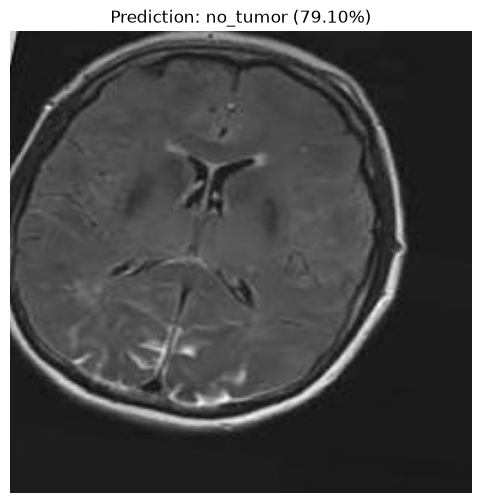

In [74]:
# Pick one unseen MRI from the classification test set
sample_image_path = test_df.iloc[0]["image_path"]

print("Testing image:")
print(sample_image_path)

# Run the complete pipeline
result = predict_brain_mri(sample_image_path)

In [75]:

# Improved U-Net Loss & Metrics
def soft_dice_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true * y_pred, axis=1)

    dice = (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true, axis=1)
        + tf.reduce_sum(y_pred, axis=1)
        + smooth
    )

    return tf.reduce_mean(dice)


def dice_loss(y_true, y_pred):
    return 1.0 - soft_dice_score(y_true, y_pred)


def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    return tf.reduce_mean(bce) + dice_loss(
        y_true,
        y_pred
    )


# Thresholded Dice for evaluation
def dice_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=1
    )

    dice = (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true, axis=1)
        + tf.reduce_sum(y_pred, axis=1)
        + smooth
    )

    return tf.reduce_mean(dice)


def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=1
    )

    union = (
        tf.reduce_sum(y_true, axis=1)
        + tf.reduce_sum(y_pred, axis=1)
        - intersection
    )

    iou = (intersection + smooth) / (union + smooth)

    return tf.reduce_mean(iou)


print(" Improved U-Net loss and evaluation metrics are ready")

 Improved U-Net loss and evaluation metrics are ready


In [76]:
segmentation_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[
        dice_score,
        iou_score
    ]
)

print(" U-Net recompiled")

 U-Net recompiled


In [77]:

# Retrain U-Net with corrected Dice loss


segmentation_checkpoint = ModelCheckpoint(
    "best_light_unet_128_final.keras",
    monitor="val_dice_score",
    mode="max",
    save_best_only=True,
    verbose=1
)

segmentation_early_stopping = EarlyStopping(
    monitor="val_dice_score",
    mode="max",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

segmentation_reduce_lr = ReduceLROnPlateau(
    monitor="val_dice_score",
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

final_seg_history = segmentation_model.fit(
    seg_train_ds,
    validation_data=seg_validation_ds,
    epochs=5,
    callbacks=[
        segmentation_checkpoint,
        segmentation_early_stopping,
        segmentation_reduce_lr
    ],
    verbose=1
)

Epoch 1/5


C:\Users\A C E R\Desktop\brain-tumor-classification\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - dice_score: 0.6949 - iou_score: 0.5758 - loss: 1.1959
Epoch 1: val_dice_score improved from None to 0.63924, saving model to best_light_unet_128_final.keras

Epoch 1: finished saving model to best_light_unet_128_final.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 66s 280ms/step - dice_score: 0.6949 - iou_score: 0.5758 - loss: 1.1959 - val_dice_score: 0.6392 - val_iou_score: 0.5181 - val_loss: 1.1500 - learning_rate: 1.0000e-04
Epoch 2/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - dice_score: 0.7223 - iou_score: 0.6084 - loss: 1.1308
Epoch 2: val_dice_score improved from 0.63924 to 0.67831, saving model to best_light_unet_128_final.keras

Epoch 2: finished saving model to best_light_unet_128_final.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 57s 274ms/step - dice_score: 0.7223 - iou_score: 0.6084 - loss: 1.1308 - val_dice_score: 0.6783 - val_iou_score: 0.5704 - val_loss: 1.0870 - learning_rate: 1.0000e-04
Epoch 3/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - di

In [78]:
# Final U-Net Test Evaluation


test_loss, test_dice, test_iou = segmentation_model.evaluate(
    seg_test_ds,
    verbose=1
)

print("\n" + "=" * 45)
print("FINAL U-NET SEGMENTATION RESULTS")
print("=" * 45)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f} ({test_dice * 100:.2f}%)")
print(f"Test IoU  : {test_iou:.4f} ({test_iou * 100:.2f}%)")

54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - dice_score: 0.7072 - iou_score: 0.5991 - loss: 1.0032

FINAL U-NET SEGMENTATION RESULTS
Test Loss : 1.0032
Test Dice : 0.7072 (70.72%)
Test IoU  : 0.5991 (59.91%)


In [79]:


# Save EfficientNetB3 classifier
classification_model.save(
    "best_efficientnetb3_final.keras"
)

# Save U-Net segmentation model
segmentation_model.save(
    "best_light_unet_128_final.keras"
)

print(" FINAL MODELS SAVED")
print()
print("1. best_efficientnetb3_final.keras")
print("2. best_light_unet_128_final.keras")

 FINAL MODELS SAVED

1. best_efficientnetb3_final.keras
2. best_light_unet_128_final.keras
